# 06 — Sentiment Scoring with FinBERT
Score Reddit posts and news headlines, aggregate to a daily sentiment index.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.nn.functional import softmax
import os

plt.rcParams['figure.dpi'] = 120
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Load Models

Two models — each optimised for its source:
- **FinBERT** (`ProsusAI/finbert`) for news headlines — trained on financial news (Reuters, Bloomberg)
- **RoBERTa** (`cardiffnlp/twitter-roberta-base-sentiment-latest`) for Reddit — trained on social media text

In [2]:
# FinBERT — for news headlines
FINBERT_NAME = 'ProsusAI/finbert'
finbert_tokenizer = AutoTokenizer.from_pretrained(FINBERT_NAME)
finbert = AutoModelForSequenceClassification.from_pretrained(FINBERT_NAME).to(DEVICE)
finbert.eval()
print('FinBERT loaded. Labels:', finbert.config.id2label)

# RoBERTa — for Reddit posts (social media language)
ROBERTA_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'
roberta_tokenizer = AutoTokenizer.from_pretrained(ROBERTA_NAME)
roberta = AutoModelForSequenceClassification.from_pretrained(ROBERTA_NAME).to(DEVICE)
roberta.eval()
print('RoBERTa loaded. Labels:', roberta.config.id2label)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT loaded. Labels: {0: 'positive', 1: 'negative', 2: 'neutral'}


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


RoBERTa loaded. Labels: {0: 'negative', 1: 'neutral', 2: 'positive'}


## 2. Scoring function

In [3]:
def score_with_finbert(texts: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score texts with FinBERT. Used for financial news headlines.
    Label order: positive=0, negative=1, neutral=2
    sentiment_score = positive - negative
    """
    all_pos, all_neg, all_neu = [], [], []

    # Process in chunks of batch_size — GPU handles all texts in a chunk in parallel
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]

        # Tokenize: pad shorter texts to match the longest in this batch,
        # truncate anything over 512 tokens (BERT's hard limit)
        enc = finbert_tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)

        with torch.no_grad():  # no gradients needed — inference only, saves memory
            # Run the batch through the model, then convert raw logits → probabilities
            # softmax over dim=-1 (the 3 class scores) so each row sums to 1
            # .cpu() moves the result off the GPU back to RAM; .numpy() for indexing
            probs = softmax(finbert(**enc).logits, dim=-1).cpu().numpy()

        # probs shape: (batch_size, 3) — each row is one text, each column one class
        all_pos.extend(probs[:, 0])  # FinBERT label 0 = positive
        all_neg.extend(probs[:, 1])  # FinBERT label 1 = negative
        all_neu.extend(probs[:, 2])  # FinBERT label 2 = neutral

    return pd.DataFrame({
        'positive': all_pos, 'negative': all_neg, 'neutral': all_neu,
        # score in [-1, 1]: +1 = fully positive, -1 = fully negative, 0 = neutral
        'sentiment_score': np.array(all_pos) - np.array(all_neg),
    })


def score_with_roberta(texts: list, batch_size: int = 32) -> pd.DataFrame:
    """
    Score texts with Twitter-RoBERTa. Used for Reddit posts.
    Label order: negative=0, neutral=1, positive=2
    sentiment_score = positive - negative
    """
    all_pos, all_neg, all_neu = [], [], []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = roberta_tokenizer(batch, padding=True, truncation=True,
                                max_length=512, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            probs = softmax(roberta(**enc).logits, dim=-1).cpu().numpy()

        # RoBERTa label order differs from FinBERT — must map columns correctly
        # or sentiment scores will be flipped for Reddit posts
        all_neg.extend(probs[:, 0])  # RoBERTa label 0 = negative
        all_neu.extend(probs[:, 1])  # RoBERTa label 1 = neutral
        all_pos.extend(probs[:, 2])  # RoBERTa label 2 = positive

    return pd.DataFrame({
        'positive': all_pos, 'negative': all_neg, 'neutral': all_neu,
        'sentiment_score': np.array(all_pos) - np.array(all_neg),
    })


# ── Model comparison on same test texts ──────────────────────────────────────
test_texts = [
    'Silver is going to the moon! Buy buy buy!',       # retail bullish slang
    'Silver prices crash amid rising dollar and Fed hawkishness.',  # formal bearish
    'Silver traded flat today with low volume.',        # neutral
]

print('=== FinBERT (trained on financial news) ===')
print(score_with_finbert(test_texts)[['positive', 'negative', 'neutral', 'sentiment_score']].round(3).to_string())

print('\n=== RoBERTa (trained on social media) ===')
print(score_with_roberta(test_texts)[['positive', 'negative', 'neutral', 'sentiment_score']].round(3).to_string())


=== FinBERT (trained on financial news) ===
   positive  negative  neutral  sentiment_score
0     0.050     0.034    0.916            0.016
1     0.048     0.870    0.082           -0.822
2     0.061     0.882    0.058           -0.821

=== RoBERTa (trained on social media) ===
   positive  negative  neutral  sentiment_score
0     0.967     0.004    0.029            0.964
1     0.018     0.572    0.410           -0.554
2     0.046     0.146    0.808           -0.100


## 3. Score Reddit posts

In [4]:
import pandas as pd                                                                                                  
df = pd.read_csv('../data/raw/reddit_history.csv', parse_dates=['created_utc'])                                         
print(df.shape)                         
print(df['subreddit'].value_counts())                                                                                
print(df['created_utc'].min(), "→", df['created_utc'].max())                                                         
print(df['created_utc'].dt.year.value_counts().sort_index())

(110789, 8)
subreddit
Silverbugs          75448
Wallstreetsilver    35341
Name: count, dtype: int64
2015-03-28 07:16:40 → 2026-05-03 22:59:11
created_utc
2015     4000
2016     5200
2017     5248
2018     5216
2019     5236
2020     5200
2021     9300
2022    10400
2023    10416
2024    10580
2025    29716
2026    10277
Name: count, dtype: int64


In [5]:
df.head()

,id,subreddit,created_utc,title,selftext,score,num_comments,upvote_ratio
0,30kwv5,Silverbugs,2015-03-28 07:16:40,Help?,I recently purchased a 1/2 oz. Silver Armenian...,12,11,1.0
1,30lmom,Silverbugs,2015-03-28 14:21:30,Air-Tite for 2oz Libertad - 48 x 4.5 mm with r...,Just ordered up some of the new 2oz Libertads ...,1,0,1.0
2,30meuf,Silverbugs,2015-03-28 18:39:24,My 1943 uncirculated set came in this morning....,NaN,22,12,1.0
3,30meyn,Silverbugs,2015-03-28 18:40:32,How did I do today?,NaN,10,13,1.0
4,30mg2a,Silverbugs,2015-03-28 18:49:59,My first one & I dig it. This could be dangero...,NaN,44,34,1.0


       reddit_posts  news_articles
count   4055.000000    4055.000000
mean      27.321578      15.430826
std       35.625224      16.776384
min        0.000000       0.000000
25%        0.000000       0.000000
50%       16.000000      12.000000
75%       42.000000      25.000000
max      200.000000     150.000000


<Axes: title={'center': 'Daily post/article counts'}>

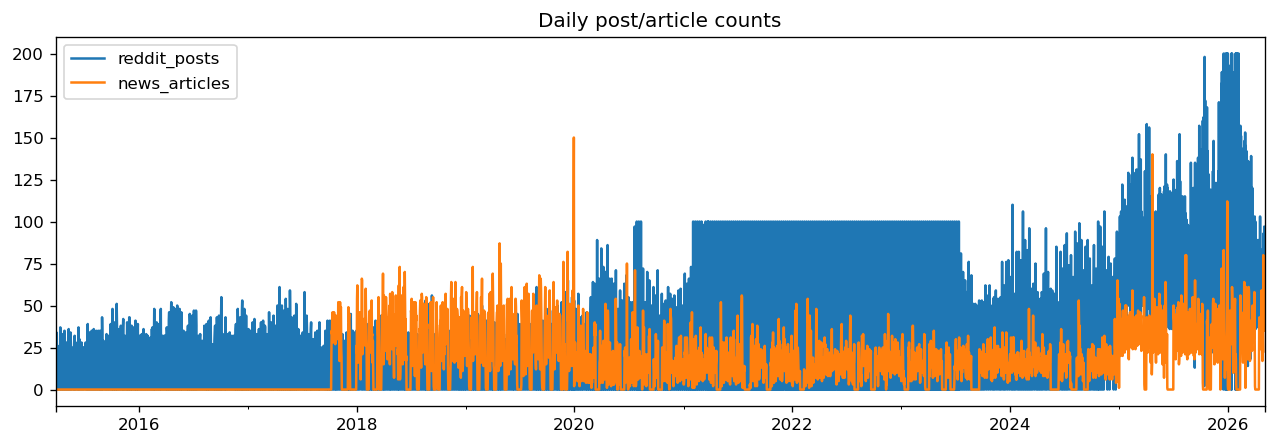

In [6]:
import pandas as pd
                                                                                                  
reddit = pd.read_csv('../data/raw/reddit_history.csv', parse_dates=['created_utc'])
news   = pd.read_csv('../data/raw/news_gdelt.csv')                                                
news['date'] = pd.to_datetime(news['seendate'], format='%Y%m%dT%H%M%SZ', errors='coerce')
                                                                                                  
reddit_daily = reddit.set_index('created_utc').resample('D').size().rename('reddit_posts')
news_daily   = news.set_index('date').resample('D').size().rename('news_articles')                
                                                                                                  
counts = pd.concat([reddit_daily, news_daily], axis=1).fillna(0).astype(int)                      
print(counts.describe())                                                                          
counts.plot(figsize=(13, 4), title='Daily post/article counts')       

In [7]:
reddit_path = '../data/raw/reddit_history.csv'

if os.path.exists(reddit_path):
    reddit = pd.read_csv(reddit_path, parse_dates=['created_utc'])
    reddit = reddit.dropna(subset=['title'])

    # Combine title + first 100 chars of body for more signal
    reddit['text'] = reddit['title'] + '. ' + reddit['selftext'].fillna('').str[:100]

    # Use RoBERTa — better suited for Reddit's informal language than FinBERT
    print(f'Scoring {len(reddit):,} Reddit posts with RoBERTa...')
    scores = score_with_roberta(reddit['text'].tolist())

    # Attach sentiment columns to the original DataFrame (reset index so concat aligns)
    reddit = pd.concat([reddit.reset_index(drop=True), scores], axis=1)
    reddit['date'] = pd.to_datetime(reddit['created_utc']).dt.date

    # Weight by upvotes — a post with 5000 upvotes carries more community signal
    # than one with 1; clip at 1 so downvoted/zero-score posts still contribute minimally
    reddit['weight'] = reddit['score'].clip(lower=1)
    reddit['weighted_sentiment'] = reddit['sentiment_score'] * reddit['weight']

    daily_reddit = (
        reddit.groupby('date')
        .agg(
            reddit_sentiment=('weighted_sentiment', 'sum'),  # sum of weight * sentiment
            reddit_weight_sum=('weight', 'sum'),             # sum of weights (denominator)
            reddit_post_count=('sentiment_score', 'count'),  # number of posts that day
        )
        # Divide to get weighted average — keeps the score in [-1, 1] regardless of post volume
        .assign(reddit_sentiment=lambda d: d['reddit_sentiment'] / d['reddit_weight_sum'])
    )
    daily_reddit.index = pd.to_datetime(daily_reddit.index)
    print(daily_reddit.tail())
else:
    print('No Reddit history file — run collect_reddit.py first.')
    daily_reddit = pd.DataFrame()


Scoring 110,789 Reddit posts with RoBERTa...
            reddit_sentiment  reddit_weight_sum  reddit_post_count
date                                                              
2026-04-29          0.066226                602                 37
2026-04-30         -0.131211               2927                 93
2026-05-01          0.216048               1230                 41
2026-05-02          0.201919               1506                 97
2026-05-03          0.266282                562                 85


## 4. Score news headlines

In [8]:
news_path = '../data/raw/news_gdelt.csv'

if os.path.exists(news_path):
    news = pd.read_csv(news_path, parse_dates=['seendate'])  # GDELT uses 'seendate' not 'datetime'
    news = news.dropna(subset=['title'])  # can't score a headline that doesn't exist

    # FinBERT is English-only — filter out non-English articles before scoring
    # to avoid meaningless scores on foreign-language text
    if 'language' in news.columns:
        before = len(news)
        news = news[news['language'] == 'English']
        print(f'Language filter: {before:,} → {len(news):,} articles ({before - len(news):,} dropped)')

    print(f'Scoring {len(news):,} news headlines...')
    news_scores = score_with_finbert(news['title'].tolist())  # titles only — GDELT has no body text

    # reset_index on both sides so rows align correctly before concatenating
    news = pd.concat([news.reset_index(drop=True), news_scores], axis=1)

    # seendate is a full timestamp — strip to date only so we can group by day
    news['date'] = pd.to_datetime(news['seendate']).dt.date

    daily_news = (
        news.groupby('date')['sentiment_score']
        .agg(['mean', 'count'])  # mean sentiment + article count for that day
        .rename(columns={'mean': 'news_sentiment', 'count': 'news_article_count'})
        # no upvote weighting here — all news articles treated equally
    )
    # groupby returns plain date strings; convert to datetime to align with other DataFrames
    daily_news.index = pd.to_datetime(daily_news.index)
    print(daily_news.tail())
else:
    print('No GDELT news file — run collect_news.py first.')
    daily_news = pd.DataFrame()


Language filter: 62,558 → 9,049 articles (53,509 dropped)
Scoring 9,049 news headlines...
            news_sentiment  news_article_count
date                                          
2026-04-29        0.200282                  15
2026-04-30        0.187867                   6
2026-05-01       -0.148482                   5
2026-05-02       -0.239015                   3
2026-05-03        0.011428                   2


## 5. Combine into daily sentiment index

In [9]:
sentiment_frames = [f for f in [daily_reddit, daily_news] if not f.empty]

if sentiment_frames:
    daily_sentiment = pd.concat(sentiment_frames, axis=1).sort_index()

    # Composite score: equal weight of Reddit + news (can tune later)
    cols = [c for c in ['reddit_sentiment', 'news_sentiment'] if c in daily_sentiment.columns]
    daily_sentiment['sentiment_score'] = daily_sentiment[cols].mean(axis=1)

    # Forward-fill weekends/gaps (no posts on weekends)
    # TODO: make sure this is sensible — if we have a gap of several days, should we really carry forward the last sentiment score?
    daily_sentiment = daily_sentiment.resample('B').ffill()  # business days

    os.makedirs('../data/processed', exist_ok=True)
    daily_sentiment.to_csv('../data/processed/daily_sentiment.csv')
    print('Saved:', daily_sentiment.shape)
    daily_sentiment.head()
else:
    print('No sentiment data to combine yet.')


Saved: (2896, 6)


/var/folders/kv/kkh35s417ln_b0jr43q9y9h80000gn/T/ipykernel_11340/2841377093.py:4: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  daily_sentiment = pd.concat(sentiment_frames, axis=1).sort_index()


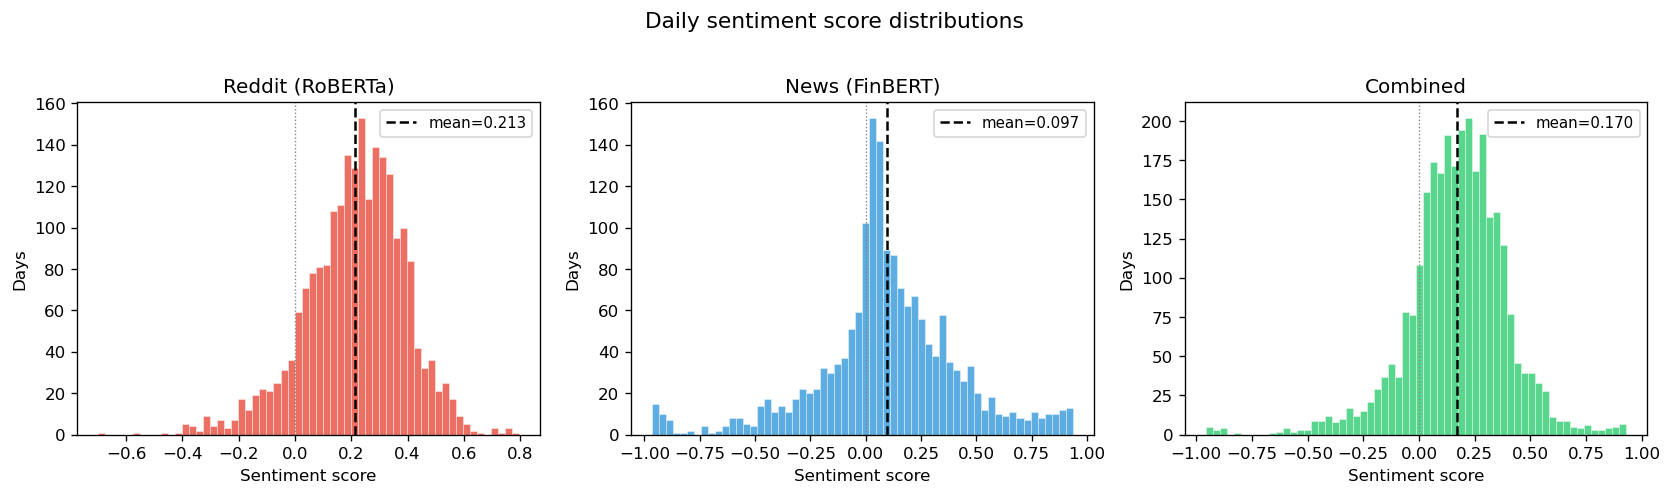

       reddit_sentiment  news_sentiment  sentiment_score
count          2225.000        1716.000         2895.000
mean              0.213           0.097            0.170
std               0.177           0.323            0.224
min              -0.699          -0.966           -0.957
25%               0.110          -0.030            0.056
50%               0.227           0.079            0.181
75%               0.334           0.266            0.303
max               0.795           0.934            0.930


In [10]:
## 6. Sentiment distribution

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col, label, color in zip(
    axes,
    ['reddit_sentiment', 'news_sentiment', 'sentiment_score'],
    ['Reddit (RoBERTa)', 'News (FinBERT)', 'Combined'],
    ['#e74c3c', '#3498db', '#2ecc71'],
):
    data = daily_sentiment[col].dropna()
    ax.hist(data, bins=60, color=color, alpha=0.8, edgecolor='white', linewidth=0.3)
    ax.axvline(data.mean(), color='black', lw=1.5, ls='--', label=f'mean={data.mean():.3f}')
    ax.axvline(0, color='grey', lw=0.8, ls=':')
    ax.set_title(label)
    ax.set_xlabel('Sentiment score')
    ax.set_ylabel('Days')
    ax.legend(fontsize=9)

plt.suptitle('Daily sentiment score distributions', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(daily_sentiment[['reddit_sentiment', 'news_sentiment', 'sentiment_score']].describe().round(3))